In [1]:
## IMPORTS ##
####################################

# torch
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models
import torchvision.transforms as transforms
from torchsummary import summary
from torch.utils.data import DataLoader, Dataset, random_split
import torch.optim as optim
from torch.cuda.amp import GradScaler, autocast

#scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score, recall_score, f1_score

# general
import numpy as np
import os
import gc
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import time
import sys

# imagery
# import tifffile as tiff
# from PIL import Image
# import rasterio

# hdf5
import h5py

# xarray
import xarray as xr



In [34]:
## =========================================== ##
## GET LAKE AREA INFORMATION FROM DUNMIRE DATA ##
## =========================================== ##

# load, filter & sort
ds = xr.open_dataset("/home/jupyter/repos/lake-vision/sandbox/all_lakes_2019.nc")
ds_CW = (
    ds
    .sel(ids=ds.ids.str.contains("CW"))
    .sortby("ids")
    .sel(time=slice("2019-05-01", "2019-09-30"))
)

# ffill + bfill to eliminate NaNs
df = ds_CW.to_dataframe().groupby(level="ids").ffill().bfill()
ds_CW = df.to_xarray()

# compute the date of max water
date_maxwater_S2 = ds_CW.S2_water.idxmax(dim="time")
date_maxwater_LS = ds_CW.LS_water.idxmax(dim="time")

# add it back into the dataset
ds_CW = ds_CW.assign(date_maxwater_S2=date_maxwater_S2)
ds_CW = ds_CW.assign(date_maxwater_LS=date_maxwater_LS)

ds_CW


<xarray.Dataset> Size: 11MB
Dimensions:           (ids: 1000, time: 153)
Coordinates:
  * ids               (ids) object 8kB 'CW2019_1524' ... 'CW2019_2523'
  * time              (time) datetime64[ns] 1kB 2019-05-01 ... 2019-09-30
Data variables:
    S1_image_id       (ids, time) object 1MB '' ... 'S1A_IW_GRDH_1SDH_2019093...
    S1_code           (ids, time) object 1MB '' '25-A-2' ... '25-B-2' '127-A-2'
    HV_lake           (ids, time) float64 1MB -15.7 -15.7 ... -18.5 -18.64
    HV_out            (ids, time) float64 1MB -14.74 -14.74 ... -18.0 -18.27
    S2_water          (ids, time) float64 1MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
    S2_zenith         (ids, time) float64 1MB 53.52 53.52 53.52 ... 71.16 71.16
    LS_water          (ids, time) float64 1MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
    LS_zenith         (ids, time) float64 1MB 52.81 52.81 52.81 ... 71.68 71.68
    t2m               (ids, time) float64 1MB 270.8 271.9 270.0 ... 267.7 268.2
    date_maxwater_S2  (ids) datetime64[ns] 8kB 2019-08-10 ... 2019-06-13
    date_maxwater_LS  (ids) datetime64[ns] 8kB 2019-08-11 ... 2019-06-08

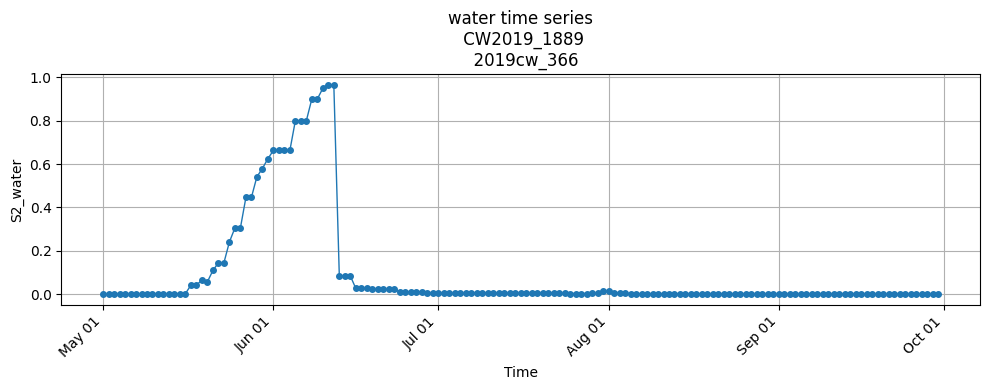

In [33]:
## ========================= ##
## PLOT AREA CURVE TO VERIFY ##
## ========================= ##

idx_lake = 365
times = ds_CW.time.values
values = ds_CW.S2_water[idx_lake].values

# drop NaNs
mask = ~np.isnan(values)
times = times[mask]
values = values[mask]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(times, values, 'o-', linewidth=1, markersize=4)

# set the major ticks to the 1st of each month
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonthday=1))

# format those ticks however you like; here: “Jan 01” 
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))

# rotate for readability
plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

ax.set_xlabel("Time")
ax.set_ylabel("S2_water")
ax.set_title(f"water time series\n {ds_CW.ids[idx_lake].values}\n  2019cw_{idx_lake+1}")
ax.grid(True)
plt.tight_layout()
plt.show()



In [38]:
## ======================== ##
## LOAD DATAFRAME OF LABELS ##
## ======================== ##

df_labels = pd.read_csv("/home/jupyter/repos/lake-vision/sandbox/labels_2019cw.csv")

df_labels


,id,area,elevation,region,year,centroid_x,centroid_y,drain_startdate,ND_HF_O,confidence,WV_ev_dates,labeled,notes,lakenum
0,00000000000000000000,1.768724e+06,1248.262075,CW,2019,-48.43304,69.12863,20190630.0,2,0,NaN,1,NaN,2019cw_1
1,00000000000000000001,2.318264e+05,1088.314082,CW,2019,-49.22777,68.80557,20190601.0,2,1,NaN,1,NaN,2019cw_2
2,00000000000000000002,1.020128e+06,1123.283760,CW,2019,-48.98180,68.91305,20190708.0,2,1,NaN,1,NaN,2019cw_3
3,00000000000000000003,2.740640e+05,1562.007250,CW,2019,-48.00056,69.48132,NaN,0,1,NaN,1,NaN,2019cw_4
4,00000000000000000004,1.331687e+05,985.853913,CW,2019,-48.79066,69.16908,20190531.0,2,1,NaN,1,NaN,2019cw_5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,000000000000000003e3,3.595101e+05,690.853636,CW,2019,-49.40981,69.26286,20190603.0,2,1,NaN,1,moulin to west,2019cw_996
996,000000000000000003e4,5.458555e+05,1097.237436,CW,2019,-49.04609,69.41549,20190707.0,1,1,NaN,1,NaN,2019cw_997
997,000000000000000003e5,2.377039e+05,1175.152165,CW,2019,-48.97477,69.44839,20190624.0,2,1,NaN,1,NaN,2019cw_998
998,000000000000000003e6,2.995160e+05,682.994738,CW,2019,-49.38901,69.28250,20190529.0,2,1,NaN,1,NaN,2019cw_999


In [40]:
## =========================================================================== ##
## COMBINING THE DUNMIRE LAKE AREA INFORMATION WITH MY LABELS INTO ONE DATASET ##
## =========================================================================== ##

# 1) read your labels CSV and index by lakenum
df_labels = (
    pd.read_csv("/home/jupyter/repos/lake-vision/sandbox/labels_2019cw.csv")
      .set_index("lakenum")
)

# 2) build the new lakenum coordinate in the same order as ds_CW.ids
#    here we assume that df_labels.lakenum is already in the order you want—
#    if not, sort df_labels.index before extracting .values
new_lakenums = df_labels.index.values
assert len(new_lakenums) == ds_CW.sizes["ids"], "mismatch in length!"

# 3) assign that as a new coordinate (so you still keep the old `ids` if you like)
ds_CW = ds_CW.assign_coords(lakenum=("ids", new_lakenums))

# 4) now pull out ND_HF_O in that order and stick it in
ndhf = df_labels["ND_HF_O"].loc[new_lakenums].values
ds_CW = ds_CW.assign(ND_HF_O=("ids", ndhf))

# inspect
ds_CW



<xarray.Dataset> Size: 11MB
Dimensions:           (ids: 1000, time: 153)
Coordinates:
  * ids               (ids) object 8kB 'CW2019_1524' ... 'CW2019_2523'
  * time              (time) datetime64[ns] 1kB 2019-05-01 ... 2019-09-30
    lakenum           (ids) object 8kB '2019cw_1' '2019cw_2' ... '2019cw_1000'
Data variables:
    S1_image_id       (ids, time) object 1MB '' ... 'S1A_IW_GRDH_1SDH_2019093...
    S1_code           (ids, time) object 1MB '' '25-A-2' ... '25-B-2' '127-A-2'
    HV_lake           (ids, time) float64 1MB -15.7 -15.7 ... -18.5 -18.64
    HV_out            (ids, time) float64 1MB -14.74 -14.74 ... -18.0 -18.27
    S2_water          (ids, time) float64 1MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
    S2_zenith         (ids, time) float64 1MB 53.52 53.52 53.52 ... 71.16 71.16
    LS_water          (ids, time) float64 1MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
    LS_zenith         (ids, time) float64 1MB 52.81 52.81 52.81 ... 71.68 71.68
    t2m               (ids, time) float64 1MB 270.8 271.9 270.0 ... 267.7 268.2
    date_maxwater_S2  (ids) datetime64[ns] 8kB 2019-08-10 ... 2019-06-13
    date_maxwater_LS  (ids) datetime64[ns] 8kB 2019-08-11 ... 2019-06-08
    ND_HF_O           (ids) int64 8kB 2 2 2 0 2 2 2 2 2 2 ... 2 2 2 2 2 1 2 2 2

In [55]:
type(ds_CW.S2_water.values)


numpy.ndarray

In [71]:
class DatasetTimeSequenceS2L8LA(Dataset):
    def __init__(self, fp_h5_images, ds_CW, seq_len=21, transform=None):
        self.fp_h5_images = fp_h5_images
        self.ds           = ds_CW
        self.seq_len      = seq_len
        self.transform    = transform

        self.area_seqs = ds_CW.S2_water.values               # (n_lakes, n_time)
        self.idx_max   = ds_CW.S2_water.argmax(dim="time").values  # (n_lakes,)
        self.labels    = ds_CW.ND_HF_O.values                 # (n_lakes,)

    def __len__(self):
        return self.ds.sizes["ids"]

    def __getitem__(self, idx):
        # 1) identify lake
        lakenum = self.ds.lakenum.values[idx]  # e.g. "2019cw_366"

        # 2) load full image sequence
        with h5py.File(self.fp_h5_images, 'r') as f:
            img_seq = f[f'cw_2019_lakenum_{lakenum}'][()]  # (T, C, H, W)

        # 3) slice window around max‐area time
        center = int(self.idx_max[idx])
        half   = self.seq_len // 2
        start  = max(0, center - half)
        end    = min(img_seq.shape[0], center + half + 1)

        if end - start < self.seq_len:
            if start == 0:
                end = min(self.seq_len, img_seq.shape[0])
            else:
                start = max(0, img_seq.shape[0] - self.seq_len)

        img_seq = img_seq[start:end]                    # (seq_len, C, H, W)
        area    = self.area_seqs[idx, start:end]        # (seq_len,)

        # 4) pull label
        label = int(self.labels[idx])

        # 5) to torch tensors
        img_seq = torch.tensor(img_seq, dtype=torch.float32)
        area    = torch.tensor(area,   dtype=torch.float32).unsqueeze(-1)
        label   = torch.tensor(label,  dtype=torch.long)

        # 6) optional transform
        if self.transform:
            img_seq = self.transform(img_seq)

        return img_seq, area, label, lakenum
    
    

In [74]:
fp_h5_images = "/home/jupyter/yao_scratch/joshua/lakesproj/hdf5_files_scratch/cw_2019.hdf5"

# ds_CW must already exist from your previous steps
test_ds   = DatasetTimeSequenceS2L8LA(fp_h5_images, ds_CW, seq_len=41)
test_loader = DataLoader(test_ds, batch_size=20, shuffle=True)

# grab one batch
img_batch, area_batch, label_batch, lakenum_batch = next(iter(test_loader))

print(img_batch.shape)     # e.g. (4, 21, C, H, W)
print(area_batch.shape)    # (4, 21, 1)
print(label_batch)         # tensor([...])
print(lakenum_batch)       # list of 4 strings



torch.Size([20, 41, 7, 256, 256])
torch.Size([20, 41, 1])
tensor([2, 2, 2, 2, 2, 2, 2, 2, 0, 1, 0, 2, 2, 1, 2, 0, 1, 2, 2, 2])
('2019cw_776', '2019cw_835', '2019cw_586', '2019cw_643', '2019cw_650', '2019cw_612', '2019cw_512', '2019cw_930', '2019cw_150', '2019cw_366', '2019cw_139', '2019cw_895', '2019cw_381', '2019cw_728', '2019cw_421', '2019cw_969', '2019cw_557', '2019cw_314', '2019cw_427', '2019cw_182')


In [ ]:
## ============= ##
## DATASET CLASS ##
## ============= ##

# DEFINE THE DATASET CLASS:
class DatasetTimeSequenceS2L8LA():
    def __init__(self, fp_h5, ds_CW, seq_len=21, transform=None):
        '''
        initializes the dataset
        
        args:
            fp_h5 (str): file path to the .hdf5 file containing the lakebasin images
            df_set (dataframe): dataframe to use, either training or validation dataframe
            transform (callable, optional): optional transform to be applied on a sample
        '''
        
        # path to .hdf5 file containing the lakebasin images
        self.fp_h5 = fp_h5
        
        # load all lakearea sequences into memory, normalize and remove nans:
        self.area_seqs = ds_CW.S2_water.values
                
        # sequence length:
        self.seq_len = seq_len
        
        # transform:
        self.transform = transform  
        
    # # helper function for listing out the dataset names:
    # def _list_dataset_names(fp_h5):
    #     dataset_names = []
    #     with h5py.File(fp_h5, 'r') as h5_file:
    #         def collect_dataset_names(name,obj):
    #             if isinstance(obj, h5py.Dataset):
    #                 dataset_names.append(name)
    #         h5_file.visititems(collect_dataset_names)
    #     def extract_number(name):
    #         # Split the name by underscore and return the last part as an integer
    #         parts = name.split('_')
    #         return int(parts[-1])  # Assuming the last part is always a number
    #     dataset_names.sort(key=extract_number)
    #     return dataset_names
    
    # __len__()
    def __len__(self):
        return len(self.df_set)
    
    # __getitem__()
    def __getitem__(self, idx):
        
        # define lakenum wrt idx:
        lakenum = self.df_set['lakenum'].iloc[idx] # lakenum (e.g., 2019cw_366) 
        lakenum_int = int(lakenum.split("_")[1]) # cast as integer (e.g., 366)
        
        # access the lake area time series arrays
        area_seq = np.array(self.area_seqs[lakenum_int-1]) # note, need to do lakenum-1 because lakenum=1 corresponds to index=0
        
        # access the .hdf5 file for the time sequence imagery datasets (get lakenum, image sequence, and label):
        with h5py.File(self.fp_h5, 'r') as h5_file:
            path_dataset = f'cw_2019_lakenum_{lakenum}' # path to the dataset in the .hdf5 file
            img_seq = np.array(h5_file[path_dataset]) # image sequence
            label = int(self.df_set['ND_HF_O'].iloc[idx]) # label
            
        # access the .hdf5 file for the time sequence of lake area masks:
        with h5py.File(self.fp_h5_lamasks, 'r') as h5_file:
            path_dataset = f'cw_2019_lakenum_{lakenum}' # path to the dataset in the .hdf5 file
            lamask_seq = np.nan_to_num(np.array(h5_file[path_dataset]), nan=0.0) # image sequence
            
        # LIMIT THE IMAGE SEQUENCE TO NEAR DATE OF MAX AREA:
        # Get the index of the maximum lake area from the dataframe
        idx_date_maxareas = self.df_set['idx_date_maxareas'].iloc[idx]
        # Extract 21 days centered around idx_date_maxareas, ensuring bounds are within the sequence length
        start_idx = max(0, idx_date_maxareas - self.seq_len//2)
        end_idx = min(img_seq.shape[0], idx_date_maxareas + self.seq_len//2 + 1)  # +1 because slicing is exclusive at the end
        # Adjust start and end indices if there aren't enough days before or after
        if end_idx - start_idx < self.seq_len:
            if start_idx == 0:
                end_idx = min(self.seq_len, img_seq.shape[0])
            elif end_idx == img_seq.shape[0]:
                start_idx = max(0, img_seq.shape[0] - self.seq_len)
        # Slice the image sequence
        img_seq = img_seq[start_idx:end_idx]
        # slice the lamask_seq
        lamask_seq = lamask_seq[start_idx:end_idx]
        lamask_seq = np.expand_dims(lamask_seq, axis=1) # expand to include a channel dimension
        # slice the area sequence
        area_seq = area_seq[start_idx:end_idx]
        
        # concatenate img_seq and lamask_seq into one array:
        img_lamask_seq = np.concatenate((img_seq, lamask_seq), axis=1)
        
        # convert np arrays to tensors:
        img_lamask_seq = torch.tensor(np.asarray(img_lamask_seq))
        area_seq = torch.tensor(area_seq, dtype=torch.float32).unsqueeze(-1)  # Add singleton dimension
        label = torch.tensor(np.asarray(label))
            
        # apply transform if any:
        if self.transform:
            img_seq = self.transform(img_seq)

        # returns:
        return img_lamask_seq, area_seq, label, lakenum
